# Building a Retriever-Reader Question Answering System

Welcome! This notebook will guide you through building a modern Question Answering (QA) system from scratch. As a software engineer, you're familiar with building systems - a QA pipeline is no different. We'll break it down into two main components:

1. **The Retriever:** A fast, efficient component that "retrieves" a small subset of documents from a large knowledge base relevant to the user's question.
2. **The Reader:** A more powerful Transformer-based model that carefully reads the retrieved documents to extract the precise answer.

This two-stage approach allows QA systems to scale to millions of documents without sacrificing accuracy.

## What You'll Learn

1. How semantic embeddings work for document retrieval
2. How to use FAISS for efficient similarity search
3. How extractive QA models work (predicting answer spans)
4. How to evaluate both retriever and reader components
5. Techniques to improve your QA pipeline

## 1. Setup and Imports

All dependencies are managed through `environment.yml`. Make sure you've activated the `dl-sandbox` conda environment and run `conda env update -f environment.yml --prune` if you haven't already.

**Key Libraries:**
- `sentence-transformers`: Pre-trained models for creating semantic embeddings
- `faiss-cpu`: Facebook AI Similarity Search - efficient vector similarity search
- `transformers`: Hugging Face's transformer models for the reader
- `datasets`: Hugging Face's dataset library for loading SQuAD

In [1]:
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Hugging Face libraries
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForQuestionAnswering,
    pipeline
)
from sentence_transformers import SentenceTransformer

# Facebook AI Similarity Search
import faiss

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: mps
PyTorch version: 2.9.1


## 2. Understanding the QA Pipeline Architecture

Before diving into code, let's understand the architecture conceptually.

### The Problem with Naive QA

Imagine you have a knowledge base of 1 million documents and a question like "What is the capital of France?"

**Naive approach:** Feed every document to a powerful QA model.
- Problem: This would take forever! Transformer models are slow and expensive.

**Smart approach:** Use a two-stage pipeline.
1. **Stage 1 (Retriever):** Quickly find the top-k most relevant documents (e.g., top 5 out of 1 million)
2. **Stage 2 (Reader):** Use a powerful model to extract the answer from just these 5 documents

### How the Retriever Works

The retriever converts both questions and documents into **dense vectors (embeddings)** in the same semantic space. Similar meanings = similar vectors.

```
Question: "What is the capital of France?" -> [0.2, -0.1, 0.8, ...] (384 dimensions)
Document: "Paris is the capital of France." -> [0.21, -0.09, 0.79, ...] (similar!)
Document: "The weather is nice today." -> [-0.5, 0.3, 0.1, ...] (different!)
```

We use **cosine similarity** or **dot product** to measure how close vectors are.

### How the Reader Works

The reader is a Transformer model fine-tuned for **extractive QA**. It predicts:
- **Start position:** Where does the answer begin?
- **End position:** Where does the answer end?

```
Context: "Paris is the capital of France. It has a population of 2 million."
Question: "What is the capital of France?"
Answer: start=0, end=0 -> "Paris"
```

## 3. Loading and Exploring the Dataset

We'll use **SQuAD v1.1** (Stanford Question Answering Dataset), a classic benchmark for QA systems.

**SQuAD Structure:**
- Each example has a `context` (a paragraph from Wikipedia)
- A `question` about that context
- An `answers` object containing the text and starting position

For our retriever-reader demo, we'll treat each context as a separate "document" in our knowledge base.

In [2]:
# Load SQuAD dataset
print("Loading SQuAD dataset...")
squad = load_dataset("squad")

print(f"\nDataset structure:")
print(squad)

print(f"\nTraining examples: {len(squad['train'])}")
print(f"Validation examples: {len(squad['validation'])}")

Loading SQuAD dataset...

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

Training examples: 87599
Validation examples: 10570


In [3]:
# Examine a single example
example = squad['train'][0]

print("=" * 80)
print("EXAMPLE FROM SQUAD")
print("=" * 80)
print(f"\nID: {example['id']}")
print(f"\nTitle: {example['title']}")
print(f"\nContext (first 500 chars):\n{example['context'][:500]}...")
print(f"\nQuestion: {example['question']}")
print(f"\nAnswer: {example['answers']}")

EXAMPLE FROM SQUAD

ID: 5733be284776f41900661182

Title: University_of_Notre_Dame

Context (first 500 chars):
Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputed...

Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?

Answer: {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}


### Creating Our Knowledge Base

To simulate a real retrieval scenario, we'll extract unique contexts (documents) from SQuAD.

Note: In SQuAD, multiple questions can share the same context paragraph. We'll deduplicate to create our document corpus.

In [4]:
# Extract unique contexts as our document corpus
# We'll use a subset for faster processing in this demo
NUM_DOCS = 500  # Use 500 unique documents for the demo

# Get unique contexts from training set
seen_contexts = set()
documents = []
doc_to_questions = {}  # Map document index to its questions/answers

for item in squad['train']:
    context = item['context']
    if context not in seen_contexts and len(documents) < NUM_DOCS:
        doc_idx = len(documents)
        documents.append({
            'id': doc_idx,
            'text': context,
            'title': item['title']
        })
        seen_contexts.add(context)
        doc_to_questions[doc_idx] = []
    
    # Map questions to their documents
    if context in seen_contexts:
        doc_idx = next(i for i, d in enumerate(documents) if d['text'] == context)
        if doc_idx < NUM_DOCS:
            doc_to_questions[doc_idx].append({
                'question': item['question'],
                'answers': item['answers']
            })

print(f"Created knowledge base with {len(documents)} unique documents")
print(f"Total question-answer pairs mapped: {sum(len(v) for v in doc_to_questions.values())}")

# Show document length distribution
doc_lengths = [len(d['text']) for d in documents]
print(f"\nDocument length stats:")
print(f"  Min: {min(doc_lengths)} chars")
print(f"  Max: {max(doc_lengths)} chars")
print(f"  Mean: {np.mean(doc_lengths):.0f} chars")

Created knowledge base with 500 unique documents
Total question-answer pairs mapped: 3263

Document length stats:
  Min: 155 chars
  Max: 2132 chars
  Mean: 771 chars


## 4. Building the Retriever

Now let's build the retriever component. We'll use:

1. **Sentence-Transformers** for embedding: We'll use `all-MiniLM-L6-v2`, a lightweight but powerful model that creates 384-dimensional embeddings.
2. **FAISS** for fast similarity search: FAISS (Facebook AI Similarity Search) is optimized for searching through millions of vectors quickly.

### Why MiniLM?

- **Small:** Only 22M parameters (vs 110M for BERT-base)
- **Fast:** 5x faster than BERT-base
- **Effective:** Trained to produce semantically meaningful embeddings
- **Good for demos:** Runs well on CPU

In [5]:
# Load the embedding model
print("Loading sentence transformer model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Move to appropriate device (MPS has some issues with sentence-transformers, so we'll use CPU for encoding)
# The model will handle device placement internally
print(f"Model loaded. Embedding dimension: {embedding_model.get_sentence_embedding_dimension()}")

Loading sentence transformer model...
Model loaded. Embedding dimension: 384


### Understanding Embeddings

Let's visualize how embeddings capture semantic meaning. Similar sentences should have similar embeddings.

Sentences:
  S1: What is the capital of France?
  S2: Which city is the capital of France?
  S3: Paris is the capital of France.
  S4: The Eiffel Tower is in Paris.
  S5: How do I make a chocolate cake?


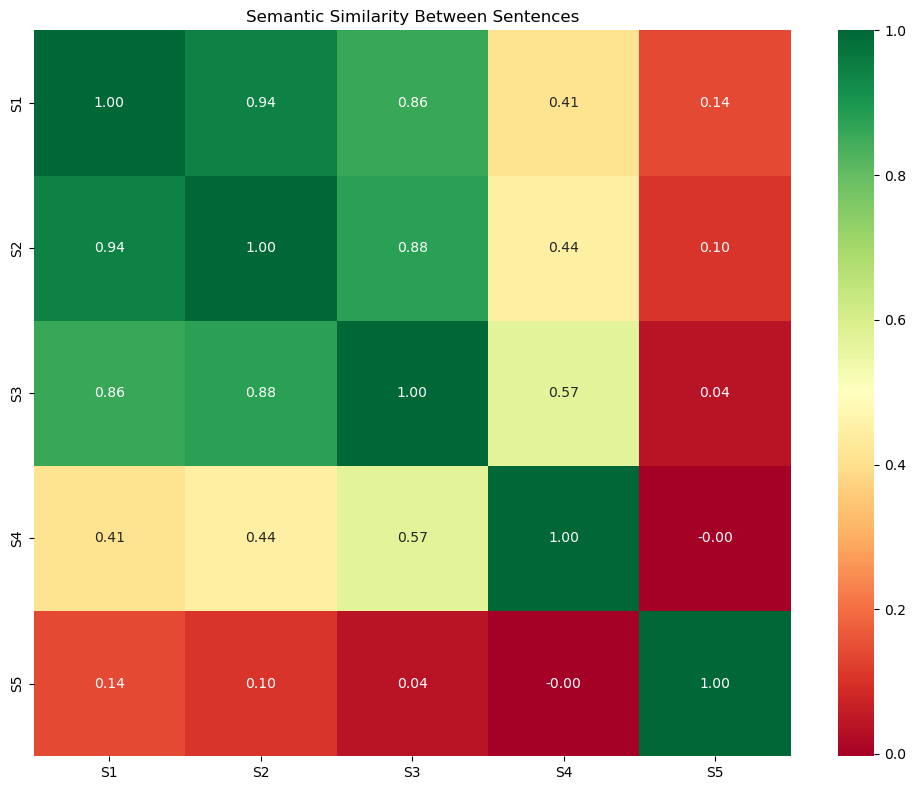

In [6]:
# Demonstrate semantic similarity with embeddings
demo_sentences = [
    "What is the capital of France?",
    "Which city is the capital of France?",  # Same meaning, different words
    "Paris is the capital of France.",  # The answer!
    "The Eiffel Tower is in Paris.",  # Related topic
    "How do I make a chocolate cake?",  # Completely different topic
]

# Get embeddings
demo_embeddings = embedding_model.encode(demo_sentences)

# Compute similarity matrix (cosine similarity)
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(demo_embeddings)

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix, 
    annot=True, 
    fmt='.2f',
    xticklabels=[f"S{i+1}" for i in range(len(demo_sentences))],
    yticklabels=[f"S{i+1}" for i in range(len(demo_sentences))],
    cmap='RdYlGn'
)
plt.title('Semantic Similarity Between Sentences')
plt.tight_layout()

# Print legend
print("Sentences:")
for i, s in enumerate(demo_sentences):
    print(f"  S{i+1}: {s}")

plt.show()

**Observations:**
- S1 and S2 have high similarity (~0.9) because they ask the same thing
- S3 (the answer) has good similarity with the questions
- S5 (chocolate cake) has low similarity with everything else - it's a different topic entirely

### Encoding Our Document Corpus

Now we'll encode all documents in our knowledge base. This is typically done **offline** (once) and stored.

In [7]:
# Encode all documents
print(f"Encoding {len(documents)} documents...")

document_texts = [doc['text'] for doc in documents]
document_embeddings = embedding_model.encode(
    document_texts, 
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nEmbeddings shape: {document_embeddings.shape}")
print(f"Each document is represented as a {document_embeddings.shape[1]}-dimensional vector")

Encoding 500 documents...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Embeddings shape: (500, 384)
Each document is represented as a 384-dimensional vector


### Building the FAISS Index

FAISS provides various index types for different speed/accuracy trade-offs:

- **IndexFlatL2/IndexFlatIP:** Exact search (brute force) - accurate but slow for large datasets
- **IndexIVFFlat:** Approximate search using clustering - faster for large datasets
- **IndexHNSW:** Graph-based approximate search - very fast

For our demo with 500 documents, `IndexFlatIP` (Inner Product / Dot Product) works well. For millions of documents, you'd use approximate methods.

In [8]:
# Build FAISS index
# We use Inner Product (IP) because our embeddings are normalized
# For normalized vectors: cosine_similarity = dot_product

embedding_dim = document_embeddings.shape[1]

# Normalize embeddings for cosine similarity via dot product
faiss.normalize_L2(document_embeddings)

# Create index
index = faiss.IndexFlatIP(embedding_dim)  # Inner Product for cosine similarity
index.add(document_embeddings)

print(f"FAISS index built!")
print(f"Index contains {index.ntotal} vectors")
print(f"Index is trained: {index.is_trained}")

FAISS index built!
Index contains 500 vectors
Index is trained: True


### Testing the Retriever

Let's test our retriever with some questions.

In [9]:
def retrieve(question: str, k: int = 5):
    """
    Retrieve the top-k most relevant documents for a question.
    
    Args:
        question: The user's question
        k: Number of documents to retrieve
    
    Returns:
        List of (document, score) tuples
    """
    # Encode the question
    question_embedding = embedding_model.encode([question], convert_to_numpy=True)
    faiss.normalize_L2(question_embedding)
    
    # Search the index
    scores, indices = index.search(question_embedding, k)
    
    # Return documents with scores
    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append((documents[idx], float(score)))
    
    return results

In [10]:
# Test retrieval with a question from our dataset
test_question = doc_to_questions[0][0]['question']  # Get first question from first document
expected_doc_idx = 0

print(f"Question: {test_question}")
print(f"Expected document index: {expected_doc_idx}")
print("\n" + "="*80)

results = retrieve(test_question, k=5)

print("\nTop 5 Retrieved Documents:")
for i, (doc, score) in enumerate(results, 1):
    is_correct = "[CORRECT]" if doc['id'] == expected_doc_idx else ""
    print(f"\n{i}. Score: {score:.4f} | Doc ID: {doc['id']} {is_correct}")
    print(f"   Title: {doc['title']}")
    print(f"   Text preview: {doc['text'][:200]}...")

Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Expected document index: 0


Top 5 Retrieved Documents:

1. Score: 0.6014 | Doc ID: 0 [CORRECT]
   Title: University_of_Notre_Dame
   Text preview: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper sta...

2. Score: 0.5004 | Doc ID: 28 
   Title: University_of_Notre_Dame
   Text preview: Because of its Catholic identity, a number of religious buildings stand on campus. The Old College building has become one of two seminaries on campus run by the Congregation of Holy Cross. The curren...

3. Score: 0.4701 | Doc ID: 38 
   Title: University_of_Notre_Dame
   Text preview: The University of Notre Dame du Lac (or simply Notre Dame /ˌnoʊtərˈdeɪm/ NOH-tər-DAYM) is a Catholic research university located adjacent to South Bend, Indiana, in the United States. In French,

## 5. Building the Reader

The reader is a Transformer model fine-tuned for **extractive question answering**. Given a context and question, it predicts the start and end positions of the answer span within the context.

We'll use `deepset/minilm-uncased-squad2`, a MiniLM model fine-tuned on SQuAD 2.0.

### How Extractive QA Works

1. **Input:** `[CLS] question [SEP] context [SEP]`
2. **Model outputs:** Two probability distributions over all tokens:
   - P(token is answer start)
   - P(token is answer end)
3. **Prediction:** Find the span (start, end) with highest combined probability

In [11]:
# Load the QA model
print("Loading QA model...")

qa_model_name = "deepset/minilm-uncased-squad2"

# We'll use the pipeline API for simplicity
# The pipeline handles tokenization, model inference, and answer extraction
qa_pipeline = pipeline(
    "question-answering",
    model=qa_model_name,
    tokenizer=qa_model_name,
    device=0 if device.type == 'cuda' else -1  # Use GPU if available (MPS not fully supported)
)

print(f"QA model loaded: {qa_model_name}")

Loading QA model...


Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


QA model loaded: deepset/minilm-uncased-squad2


### Testing the Reader

Let's test the reader in isolation first, giving it the correct context.

In [12]:
# Test the reader with a known context-question pair
test_context = documents[0]['text']
test_question = doc_to_questions[0][0]['question']
expected_answer = doc_to_questions[0][0]['answers']['text'][0]

print(f"Context (first 300 chars): {test_context[:300]}...")
print(f"\nQuestion: {test_question}")
print(f"Expected answer: {expected_answer}")

# Get model's answer
result = qa_pipeline(question=test_question, context=test_context)

print(f"\nModel's answer: {result['answer']}")
print(f"Confidence score: {result['score']:.4f}")
print(f"Start position: {result['start']}")
print(f"End position: {result['end']}")

Context (first 300 chars): Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is ...

Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Expected answer: Saint Bernadette Soubirous

Model's answer: Saint Bernadette Soubirous
Confidence score: 0.9863
Start position: 515
End position: 541


### Understanding the Reader's Output

Let's look under the hood to see how the model predicts start and end positions.

In [13]:
# Load model and tokenizer separately for deeper inspection
tokenizer = AutoTokenizer.from_pretrained(qa_model_name)
model = AutoModelForQuestionAnswering.from_pretrained(qa_model_name)
model.eval()

# Tokenize
inputs = tokenizer(
    test_question,
    test_context[:500],  # Truncate for visualization
    return_tensors="pt",
    truncation=True,
    max_length=384
)

# Get model outputs
with torch.no_grad():
    outputs = model(**inputs)

# Get start and end logits
start_logits = outputs.start_logits[0]
end_logits = outputs.end_logits[0]

# Convert to probabilities
start_probs = torch.softmax(start_logits, dim=0)
end_probs = torch.softmax(end_logits, dim=0)

# Get top predictions
start_idx = torch.argmax(start_probs).item()
end_idx = torch.argmax(end_probs).item()

# Decode the answer
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
answer_tokens = tokens[start_idx:end_idx+1]

print(f"Number of tokens: {len(tokens)}")
print(f"\nTop start position: {start_idx} (prob: {start_probs[start_idx]:.4f})")
print(f"Top end position: {end_idx} (prob: {end_probs[end_idx]:.4f})")
print(f"\nAnswer tokens: {answer_tokens}")
print(f"Decoded answer: {tokenizer.decode(inputs['input_ids'][0][start_idx:end_idx+1])}")

Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Number of tokens: 128

Top start position: 16 (prob: 0.3331)
Top end position: 127 (prob: 0.3330)

Answer tokens: ['[SEP]', 'architectural', '##ly', ',', 'the', 'school', 'has', 'a', 'catholic', 'character', '.', 'atop', 'the', 'main', 'building', "'", 's', 'gold', 'dome', 'is', 'a', 'golden', 'statue', 'of', 'the', 'virgin', 'mary', '.', 'immediately', 'in', 'front', 'of', 'the', 'main', 'building', 'and', 'facing', 'it', ',', 'is', 'a', 'copper', 'statue', 'of', 'christ', 'with', 'arms', 'up', '##rai', '##sed', 'with', 'the', 'legend', '"', 've', '##ni', '##te', 'ad', 'me', 'om', '##nes', '"', '.', 'next', 'to', 'the', 'main', 'building', 'is', 'the', 'basilica', 'of', 'the', 'sacred', 'heart', '.', 'immediately', 'behind', 'the', 'basilica', 'is', 'the', 'gr', '##otto', ',', 'a', 'marian', 'place', 'of', 'prayer', 'and', 'reflection', '.', 'it', 'is', 'a', 'replica', 'of', 'the', 'gr', '##otto', 'at', 'lou', '##rdes', ',', 'france', 'where', 'the', 'virgin', 'mary', 'reputed', '[SEP

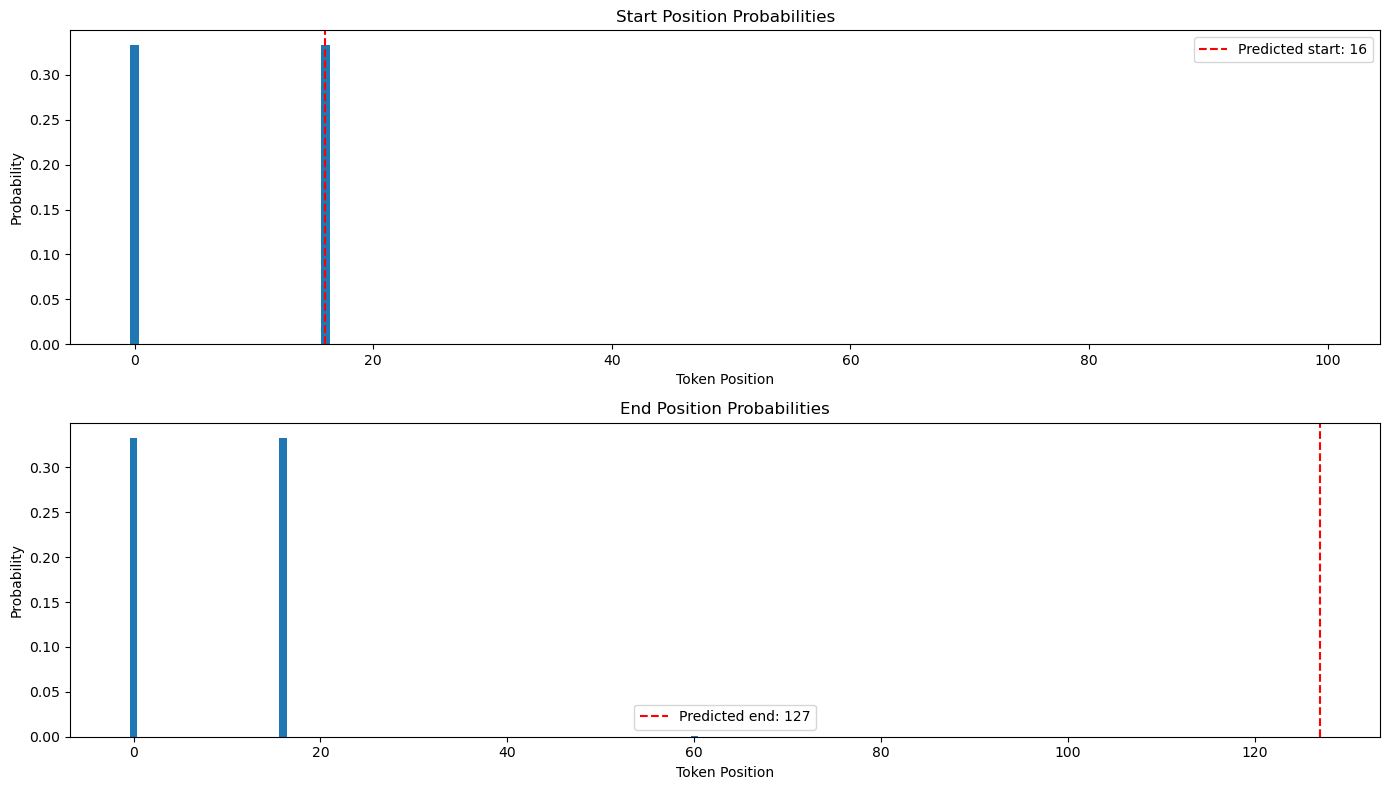


Tokens around answer (positions 13 to 128):
    13: ##rdes
    14: france
    15: ?
>>> 16: [SEP]
>>> 17: architectural
>>> 18: ##ly
>>> 19: ,
>>> 20: the
>>> 21: school
>>> 22: has
>>> 23: a
>>> 24: catholic
>>> 25: character
>>> 26: .
>>> 27: atop
>>> 28: the
>>> 29: main
>>> 30: building
>>> 31: '
>>> 32: s
>>> 33: gold
>>> 34: dome
>>> 35: is
>>> 36: a
>>> 37: golden
>>> 38: statue
>>> 39: of
>>> 40: the
>>> 41: virgin
>>> 42: mary
>>> 43: .
>>> 44: immediately
>>> 45: in
>>> 46: front
>>> 47: of
>>> 48: the
>>> 49: main
>>> 50: building
>>> 51: and
>>> 52: facing
>>> 53: it
>>> 54: ,
>>> 55: is
>>> 56: a
>>> 57: copper
>>> 58: statue
>>> 59: of
>>> 60: christ
>>> 61: with
>>> 62: arms
>>> 63: up
>>> 64: ##rai
>>> 65: ##sed
>>> 66: with
>>> 67: the
>>> 68: legend
>>> 69: "
>>> 70: ve
>>> 71: ##ni
>>> 72: ##te
>>> 73: ad
>>> 74: me
>>> 75: om
>>> 76: ##nes
>>> 77: "
>>> 78: .
>>> 79: next
>>> 80: to
>>> 81: the
>>> 82: main
>>> 83: building
>>> 84: is
>>> 85: the
>>> 86: basilica
>

In [14]:
# Visualize start/end probabilities
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Only show first 100 tokens for clarity
n_tokens = min(100, len(tokens))

axes[0].bar(range(n_tokens), start_probs[:n_tokens].numpy())
axes[0].set_xlabel('Token Position')
axes[0].set_ylabel('Probability')
axes[0].set_title('Start Position Probabilities')
axes[0].axvline(x=start_idx, color='red', linestyle='--', label=f'Predicted start: {start_idx}')
axes[0].legend()

axes[1].bar(range(n_tokens), end_probs[:n_tokens].numpy())
axes[1].set_xlabel('Token Position')
axes[1].set_ylabel('Probability')
axes[1].set_title('End Position Probabilities')
axes[1].axvline(x=end_idx, color='red', linestyle='--', label=f'Predicted end: {end_idx}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Show tokens around the answer
print(f"\nTokens around answer (positions {max(0, start_idx-3)} to {min(len(tokens), end_idx+4)}):")
for i in range(max(0, start_idx-3), min(len(tokens), end_idx+4)):
    marker = ">>>" if start_idx <= i <= end_idx else "   "
    print(f"{marker} {i}: {tokens[i]}")

## 6. Combining Retriever and Reader: The Full Pipeline

Now let's put it all together! Our full QA pipeline will:

1. Take a question
2. Retrieve the top-k most relevant documents
3. Run the reader on each retrieved document
4. Return the best answer across all documents

In [15]:
def answer_question(question: str, k: int = 5, verbose: bool = True):
    """
    Full retriever-reader QA pipeline.
    
    Args:
        question: The user's question
        k: Number of documents to retrieve
        verbose: Whether to print intermediate results
    
    Returns:
        Dictionary with answer and metadata
    """
    if verbose:
        print(f"Question: {question}")
        print("\n" + "="*80)
    
    # Step 1: Retrieve relevant documents
    if verbose:
        print("\nStep 1: RETRIEVAL")
    
    retrieved_docs = retrieve(question, k=k)
    
    if verbose:
        print(f"Retrieved {len(retrieved_docs)} documents")
        for i, (doc, score) in enumerate(retrieved_docs, 1):
            print(f"  {i}. Doc {doc['id']} (score: {score:.4f}) - {doc['title']}")
    
    # Step 2: Run reader on each document
    if verbose:
        print("\nStep 2: READING")
    
    all_answers = []
    for doc, retrieval_score in retrieved_docs:
        try:
            result = qa_pipeline(question=question, context=doc['text'])
            result['doc_id'] = doc['id']
            result['doc_title'] = doc['title']
            result['retrieval_score'] = retrieval_score
            # Combined score: reader confidence * retrieval score
            result['combined_score'] = result['score'] * retrieval_score
            all_answers.append(result)
            
            if verbose:
                print(f"  Doc {doc['id']}: \"{result['answer']}\" (conf: {result['score']:.4f})")
        except Exception as e:
            if verbose:
                print(f"  Doc {doc['id']}: Error - {str(e)[:50]}")
    
    # Step 3: Select best answer
    if not all_answers:
        return {'answer': 'No answer found', 'score': 0.0}
    
    # Sort by combined score
    all_answers.sort(key=lambda x: x['combined_score'], reverse=True)
    best_answer = all_answers[0]
    
    if verbose:
        print("\n" + "="*80)
        print(f"\nBEST ANSWER: {best_answer['answer']}")
        print(f"From document: {best_answer['doc_title']} (Doc ID: {best_answer['doc_id']})")
        print(f"Reader confidence: {best_answer['score']:.4f}")
        print(f"Retrieval score: {best_answer['retrieval_score']:.4f}")
        print(f"Combined score: {best_answer['combined_score']:.4f}")
    
    return best_answer

In [16]:
# Test the full pipeline
test_question = doc_to_questions[5][0]['question']  # Pick a question
expected = doc_to_questions[5][0]['answers']['text'][0]

print(f"Expected answer: {expected}\n")
result = answer_question(test_question)

Expected answer: 1924

Question: The granting of Doctorate degrees first occurred in what year at Notre Dame?


Step 1: RETRIEVAL
Retrieved 5 documents
  1. Doc 5 (score: 0.5485) - University_of_Notre_Dame
  2. Doc 4 (score: 0.5464) - University_of_Notre_Dame
  3. Doc 33 (score: 0.5298) - University_of_Notre_Dame
  4. Doc 19 (score: 0.5033) - University_of_Notre_Dame
  5. Doc 35 (score: 0.4834) - University_of_Notre_Dame

Step 2: READING
  Doc 5: "1924" (conf: 0.9668)
  Doc 4: "1962" (conf: 0.0001)
  Doc 33: "1849" (conf: 0.8857)
  Doc 19: "1919" (conf: 0.0074)
  Doc 35: "1898" (conf: 0.0006)


BEST ANSWER: 1924
From document: University_of_Notre_Dame (Doc ID: 5)
Reader confidence: 0.9668
Retrieval score: 0.5485
Combined score: 0.5303


In [17]:
# Test with a few more questions
test_cases = []
for doc_idx in [10, 25, 50, 100]:
    if doc_idx < len(doc_to_questions) and len(doc_to_questions[doc_idx]) > 0:
        qa = doc_to_questions[doc_idx][0]
        test_cases.append({
            'question': qa['question'],
            'expected': qa['answers']['text'][0],
            'doc_idx': doc_idx
        })

print("Testing multiple questions:")
print("=" * 80)

for i, tc in enumerate(test_cases, 1):
    print(f"\n[Test {i}]")
    print(f"Question: {tc['question']}")
    print(f"Expected: {tc['expected']}")
    print(f"From Doc: {tc['doc_idx']}")
    
    result = answer_question(tc['question'], verbose=False)
    
    print(f"Got: {result['answer']}")
    print(f"From Doc: {result.get('doc_id', 'N/A')}")
    print(f"Confidence: {result['score']:.4f}")
    
    # Check if correct document was retrieved
    correct_retrieval = result.get('doc_id') == tc['doc_idx']
    print(f"Correct document retrieved: {'Yes' if correct_retrieval else 'No'}")

Testing multiple questions:

[Test 1]
Question: What person was the Director of the Science Museum at Notre Dame in the late 19th century?
Expected: Father Joseph Carrier, C.S.C.
From Doc: 10
Got: Father Joseph Carrier, C.S.C.
From Doc: 10
Confidence: 0.4741
Correct document retrieved: Yes

[Test 2]
Question: What type of educational institute is Hesburgh given credit for creating at Notre Dame?
Expected: coeducational
From Doc: 25
Got: coeducational
From Doc: 25
Confidence: 0.7933
Correct document retrieved: Yes

[Test 3]
Question: What is displayed at Zahm House for football home games at Notre Dame?
Expected: two-story banner
From Doc: 50
Got: banner
From Doc: 50
Confidence: 0.5679
Correct document retrieved: Yes

[Test 4]
Question: in September 2010, what career area did Beyonce start exploring?
Expected: modelling
From Doc: 100
Got: solo
From Doc: 57
Confidence: 0.5882
Correct document retrieved: No


## 7. Evaluating the Retriever

A good retriever should rank the correct document highly. Common metrics include:

### Retrieval Metrics

1. **Recall@k:** What percentage of questions have the correct document in the top-k results?
2. **Mean Reciprocal Rank (MRR):** Average of 1/rank of the correct document
3. **Hit Rate:** Did we retrieve the correct document at all?

Let's evaluate our retriever on a sample of questions.

In [18]:
def evaluate_retriever(k_values=[1, 3, 5, 10], num_samples=200):
    """
    Evaluate retriever performance.
    
    For each question, we know which document it came from (ground truth).
    We measure how often the retriever finds that document.
    """
    # Collect test samples
    test_samples = []
    for doc_idx, questions in doc_to_questions.items():
        for qa in questions:
            test_samples.append({
                'question': qa['question'],
                'gold_doc_idx': doc_idx
            })
            if len(test_samples) >= num_samples:
                break
        if len(test_samples) >= num_samples:
            break
    
    print(f"Evaluating on {len(test_samples)} question-document pairs...")
    
    # Initialize metrics
    max_k = max(k_values)
    recall_at_k = {k: 0 for k in k_values}
    reciprocal_ranks = []
    
    for sample in tqdm(test_samples):
        # Retrieve top-k documents
        results = retrieve(sample['question'], k=max_k)
        retrieved_ids = [doc['id'] for doc, _ in results]
        
        # Find rank of gold document
        gold_idx = sample['gold_doc_idx']
        if gold_idx in retrieved_ids:
            rank = retrieved_ids.index(gold_idx) + 1  # 1-indexed
            reciprocal_ranks.append(1.0 / rank)
            
            # Update recall@k
            for k in k_values:
                if rank <= k:
                    recall_at_k[k] += 1
        else:
            reciprocal_ranks.append(0.0)
    
    # Compute final metrics
    n = len(test_samples)
    results = {
        'recall_at_k': {k: v / n for k, v in recall_at_k.items()},
        'mrr': np.mean(reciprocal_ranks),
        'num_samples': n
    }
    
    return results

In [19]:
# Run retriever evaluation
retriever_metrics = evaluate_retriever(k_values=[1, 3, 5, 10, 20], num_samples=200)

print("\n" + "="*50)
print("RETRIEVER EVALUATION RESULTS")
print("="*50)
print(f"\nMean Reciprocal Rank (MRR): {retriever_metrics['mrr']:.4f}")
print("\nRecall@k:")
for k, recall in retriever_metrics['recall_at_k'].items():
    print(f"  Recall@{k}: {recall:.2%}")

Evaluating on 200 question-document pairs...


  0%|          | 0/200 [00:00<?, ?it/s]


RETRIEVER EVALUATION RESULTS

Mean Reciprocal Rank (MRR): 0.7699

Recall@k:
  Recall@1: 66.00%
  Recall@3: 84.50%
  Recall@5: 91.00%
  Recall@10: 95.00%
  Recall@20: 99.00%


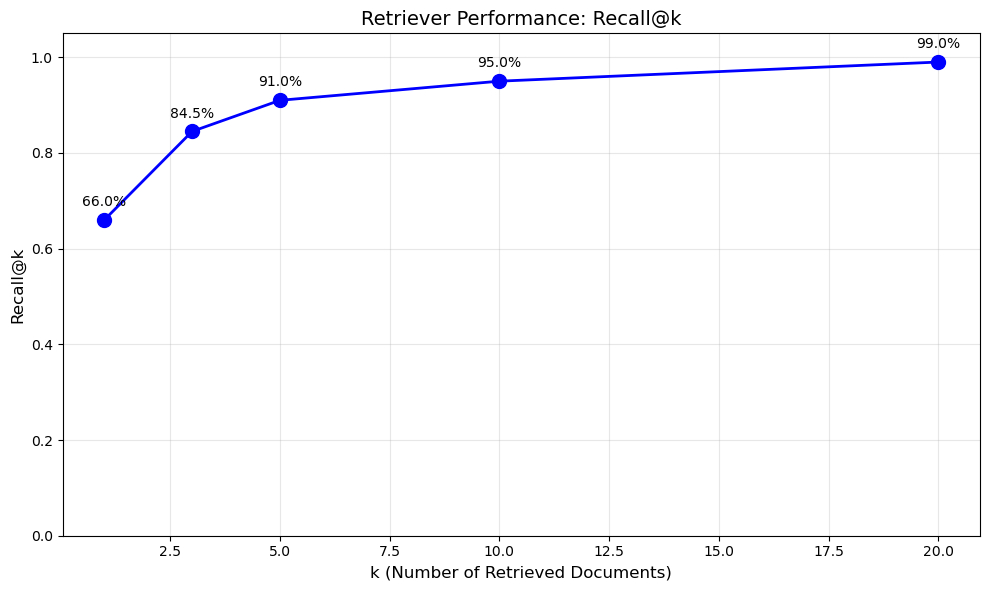

In [20]:
# Visualize retriever performance
k_values = list(retriever_metrics['recall_at_k'].keys())
recall_values = list(retriever_metrics['recall_at_k'].values())

plt.figure(figsize=(10, 6))
plt.plot(k_values, recall_values, 'bo-', linewidth=2, markersize=10)
plt.xlabel('k (Number of Retrieved Documents)', fontsize=12)
plt.ylabel('Recall@k', fontsize=12)
plt.title('Retriever Performance: Recall@k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

# Add value labels
for k, r in zip(k_values, recall_values):
    plt.annotate(f'{r:.1%}', (k, r), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

### Interpreting Retriever Metrics

- **Recall@1 ~70-80%:** The correct document is the top result most of the time
- **Recall@5 ~85-95%:** If we retrieve 5 documents, we almost always include the right one
- **MRR ~0.7-0.8:** On average, the correct document is ranked around position 1.3-1.4

These are solid results for a simple dense retriever!

## 8. Evaluating the Reader

For the reader, we use metrics from the SQuAD benchmark:

### Reader Metrics

1. **Exact Match (EM):** Does the predicted answer exactly match the gold answer?
2. **F1 Score:** Token-level overlap between predicted and gold answers

The F1 score is more forgiving - "New York City" vs "New York" would have high F1 but 0 EM.

In [21]:
import string
import re
from collections import Counter

def normalize_answer(s):
    """Normalize answer for comparison (lowercase, remove punctuation, etc.)"""
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    
    def white_space_fix(text):
        return ' '.join(text.split())
    
    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)
    
    def lower(text):
        return text.lower()
    
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def compute_exact_match(prediction, ground_truths):
    """Check if prediction exactly matches any ground truth."""
    norm_pred = normalize_answer(prediction)
    for gt in ground_truths:
        if normalize_answer(gt) == norm_pred:
            return 1.0
    return 0.0

def compute_f1(prediction, ground_truths):
    """Compute token-level F1 score."""
    def f1_single(pred, gt):
        pred_tokens = normalize_answer(pred).split()
        gt_tokens = normalize_answer(gt).split()
        
        if len(pred_tokens) == 0 or len(gt_tokens) == 0:
            return int(pred_tokens == gt_tokens)
        
        common = Counter(pred_tokens) & Counter(gt_tokens)
        num_same = sum(common.values())
        
        if num_same == 0:
            return 0.0
        
        precision = num_same / len(pred_tokens)
        recall = num_same / len(gt_tokens)
        f1 = (2 * precision * recall) / (precision + recall)
        return f1
    
    return max(f1_single(prediction, gt) for gt in ground_truths)

In [22]:
def evaluate_reader(num_samples=100):
    """
    Evaluate the reader in isolation (with gold documents).
    
    This tests: Given the correct context, can the reader extract the answer?
    """
    test_samples = []
    for doc_idx, questions in doc_to_questions.items():
        for qa in questions:
            test_samples.append({
                'question': qa['question'],
                'context': documents[doc_idx]['text'],
                'answers': qa['answers']['text']  # List of valid answers
            })
            if len(test_samples) >= num_samples:
                break
        if len(test_samples) >= num_samples:
            break
    
    print(f"Evaluating reader on {len(test_samples)} samples...")
    
    em_scores = []
    f1_scores = []
    
    for sample in tqdm(test_samples):
        # Get model prediction
        result = qa_pipeline(
            question=sample['question'],
            context=sample['context']
        )
        prediction = result['answer']
        
        # Compute metrics
        em = compute_exact_match(prediction, sample['answers'])
        f1 = compute_f1(prediction, sample['answers'])
        
        em_scores.append(em)
        f1_scores.append(f1)
    
    return {
        'exact_match': np.mean(em_scores),
        'f1': np.mean(f1_scores),
        'num_samples': len(test_samples)
    }

In [23]:
# Evaluate reader
reader_metrics = evaluate_reader(num_samples=100)

print("\n" + "="*50)
print("READER EVALUATION RESULTS (with gold context)")
print("="*50)
print(f"\nExact Match: {reader_metrics['exact_match']:.2%}")
print(f"F1 Score: {reader_metrics['f1']:.2%}")

Evaluating reader on 100 samples...


  0%|          | 0/100 [00:00<?, ?it/s]


READER EVALUATION RESULTS (with gold context)

Exact Match: 88.00%
F1 Score: 96.11%


## 9. End-to-End Evaluation

Now let's evaluate the full pipeline (retriever + reader together). This is the true test of the system.

In [24]:
def evaluate_pipeline(k=5, num_samples=100):
    """
    Evaluate the full retriever-reader pipeline.
    
    This tests the real-world scenario: Given only a question,
    can we find and extract the correct answer?
    """
    test_samples = []
    for doc_idx, questions in doc_to_questions.items():
        for qa in questions:
            test_samples.append({
                'question': qa['question'],
                'gold_doc_idx': doc_idx,
                'answers': qa['answers']['text']
            })
            if len(test_samples) >= num_samples:
                break
        if len(test_samples) >= num_samples:
            break
    
    print(f"Evaluating full pipeline on {len(test_samples)} samples (k={k})...")
    
    em_scores = []
    f1_scores = []
    retrieval_correct = 0
    
    for sample in tqdm(test_samples):
        # Run full pipeline
        result = answer_question(sample['question'], k=k, verbose=False)
        prediction = result.get('answer', '')
        
        # Check if correct document was in top-k
        if result.get('doc_id') == sample['gold_doc_idx']:
            retrieval_correct += 1
        
        # Compute metrics
        em = compute_exact_match(prediction, sample['answers'])
        f1 = compute_f1(prediction, sample['answers'])
        
        em_scores.append(em)
        f1_scores.append(f1)
    
    return {
        'exact_match': np.mean(em_scores),
        'f1': np.mean(f1_scores),
        'retrieval_accuracy': retrieval_correct / len(test_samples),
        'num_samples': len(test_samples),
        'k': k
    }

In [25]:
# Evaluate at different values of k
pipeline_results = {}
for k in [1, 3, 5, 10]:
    print(f"\nEvaluating with k={k}...")
    pipeline_results[k] = evaluate_pipeline(k=k, num_samples=100)


Evaluating with k=1...
Evaluating full pipeline on 100 samples (k=1)...


  0%|          | 0/100 [00:00<?, ?it/s]


Evaluating with k=3...
Evaluating full pipeline on 100 samples (k=3)...


  0%|          | 0/100 [00:00<?, ?it/s]


Evaluating with k=5...
Evaluating full pipeline on 100 samples (k=5)...


  0%|          | 0/100 [00:00<?, ?it/s]


Evaluating with k=10...
Evaluating full pipeline on 100 samples (k=10)...


  0%|          | 0/100 [00:00<?, ?it/s]

In [26]:
# Display results
print("\n" + "="*60)
print("FULL PIPELINE EVALUATION RESULTS")
print("="*60)

results_df = pd.DataFrame([
    {
        'k': k,
        'Exact Match': f"{r['exact_match']:.2%}",
        'F1 Score': f"{r['f1']:.2%}",
        'Retrieval Accuracy': f"{r['retrieval_accuracy']:.2%}"
    }
    for k, r in pipeline_results.items()
])

print(results_df.to_string(index=False))


FULL PIPELINE EVALUATION RESULTS
 k Exact Match F1 Score Retrieval Accuracy
 1      56.00%   64.77%             65.00%
 3      69.00%   76.41%             77.00%
 5      74.00%   81.41%             82.00%
10      77.00%   84.48%             85.00%


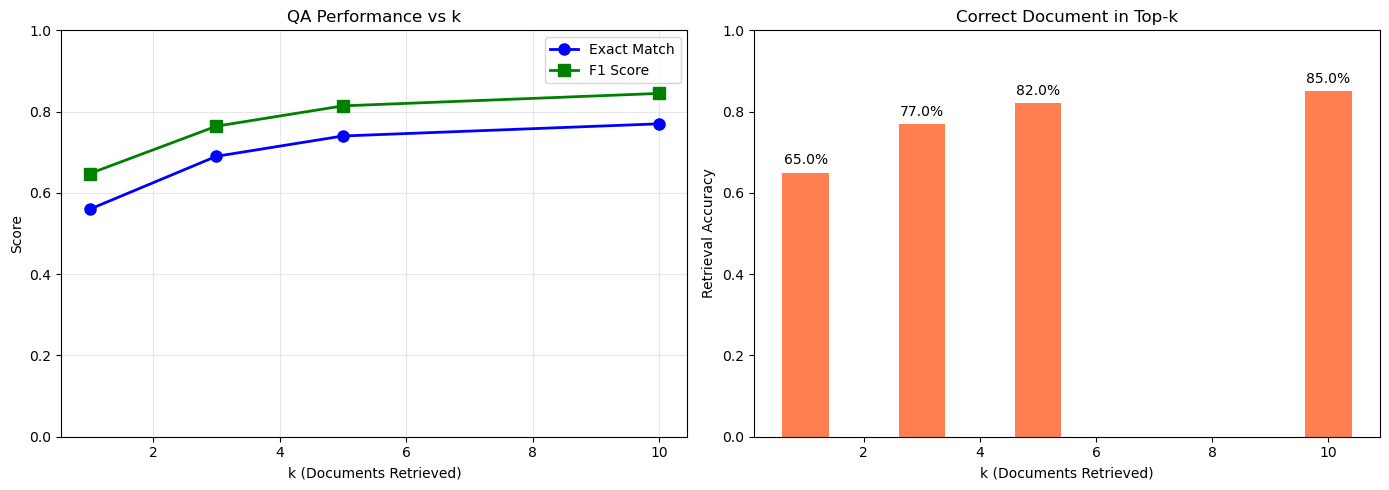

In [27]:
# Visualize pipeline performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_vals = list(pipeline_results.keys())
em_vals = [pipeline_results[k]['exact_match'] for k in k_vals]
f1_vals = [pipeline_results[k]['f1'] for k in k_vals]
ret_vals = [pipeline_results[k]['retrieval_accuracy'] for k in k_vals]

# Left plot: EM and F1
axes[0].plot(k_vals, em_vals, 'bo-', label='Exact Match', linewidth=2, markersize=8)
axes[0].plot(k_vals, f1_vals, 'gs-', label='F1 Score', linewidth=2, markersize=8)
axes[0].set_xlabel('k (Documents Retrieved)')
axes[0].set_ylabel('Score')
axes[0].set_title('QA Performance vs k')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Right plot: Retrieval accuracy
axes[1].bar(k_vals, ret_vals, color='coral')
axes[1].set_xlabel('k (Documents Retrieved)')
axes[1].set_ylabel('Retrieval Accuracy')
axes[1].set_title('Correct Document in Top-k')
axes[1].set_ylim(0, 1)

for i, (k, v) in enumerate(zip(k_vals, ret_vals)):
    axes[1].text(k, v + 0.02, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

### Key Observations

1. **Retrieval is crucial:** If the retriever fails (wrong documents), the reader can't help
2. **k trade-off:** Higher k = better recall but more noise for the reader
3. **Error propagation:** Pipeline EM is lower than reader-only EM due to retrieval errors

## 10. Improving the QA Pipeline

Now let's explore techniques to improve our pipeline. We'll cover:

1. **Better Retrieval:** Using a specialized passage retriever
2. **Re-ranking:** Using a cross-encoder to re-rank retrieved documents
3. **Answer Aggregation:** Better strategies for combining multiple answers

### 10.1 Cross-Encoder Re-ranking

The bi-encoder (our current retriever) encodes questions and documents separately. This is fast but may miss nuanced interactions.

A **cross-encoder** processes question and document together, capturing fine-grained interactions at the cost of speed.

**Strategy:** Use bi-encoder for fast initial retrieval (top-100), then cross-encoder to re-rank to top-5.

In [28]:
from sentence_transformers import CrossEncoder

# Load a cross-encoder model for re-ranking
print("Loading cross-encoder for re-ranking...")
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
print("Cross-encoder loaded!")

Loading cross-encoder for re-ranking...
Cross-encoder loaded!


In [29]:
def retrieve_with_reranking(question: str, initial_k: int = 20, final_k: int = 5):
    """
    Two-stage retrieval with cross-encoder re-ranking.
    
    Stage 1: Bi-encoder retrieves initial_k documents (fast)
    Stage 2: Cross-encoder re-ranks to final_k documents (accurate)
    """
    # Stage 1: Fast retrieval
    initial_results = retrieve(question, k=initial_k)
    
    # Stage 2: Cross-encoder scoring
    pairs = [(question, doc['text']) for doc, _ in initial_results]
    cross_scores = cross_encoder.predict(pairs)
    
    # Combine results with cross-encoder scores
    reranked = []
    for (doc, bi_score), cross_score in zip(initial_results, cross_scores):
        reranked.append((doc, float(cross_score), bi_score))
    
    # Sort by cross-encoder score
    reranked.sort(key=lambda x: x[1], reverse=True)
    
    return reranked[:final_k]

In [30]:
# Compare retrieval with and without re-ranking
test_q = doc_to_questions[15][0]['question']
gold_doc_idx = 15

print(f"Question: {test_q}")
print(f"Gold document index: {gold_doc_idx}")

print("\n--- Without Re-ranking (Bi-encoder only) ---")
basic_results = retrieve(test_q, k=5)
for i, (doc, score) in enumerate(basic_results, 1):
    marker = "[GOLD]" if doc['id'] == gold_doc_idx else ""
    print(f"  {i}. Doc {doc['id']} - Score: {score:.4f} {marker}")

print("\n--- With Cross-encoder Re-ranking ---")
reranked_results = retrieve_with_reranking(test_q, initial_k=20, final_k=5)
for i, (doc, cross_score, bi_score) in enumerate(reranked_results, 1):
    marker = "[GOLD]" if doc['id'] == gold_doc_idx else ""
    print(f"  {i}. Doc {doc['id']} - Cross: {cross_score:.4f}, Bi: {bi_score:.4f} {marker}")

Question: How many undergrads were attending Notre Dame in 2014?
Gold document index: 15

--- Without Re-ranking (Bi-encoder only) ---
  1. Doc 8 - Score: 0.6586 
  2. Doc 4 - Score: 0.6205 
  3. Doc 40 - Score: 0.6005 
  4. Doc 15 - Score: 0.5789 [GOLD]
  5. Doc 9 - Score: 0.5688 

--- With Cross-encoder Re-ranking ---
  1. Doc 15 - Cross: 6.3757, Bi: 0.5789 [GOLD]
  2. Doc 8 - Cross: 4.3311, Bi: 0.6586 
  3. Doc 9 - Cross: 1.6128, Bi: 0.5688 
  4. Doc 40 - Cross: 0.8947, Bi: 0.6005 
  5. Doc 47 - Cross: 0.3151, Bi: 0.4320 


### 10.2 Improved Answer Aggregation

When we get answers from multiple documents, we can use smarter aggregation:

1. **Confidence weighting:** Weight by reader confidence
2. **Answer voting:** If multiple documents give the same answer, boost it
3. **Source diversity:** Prefer answers supported by diverse sources

In [31]:
def answer_question_improved(question: str, k: int = 5, use_reranking: bool = True):
    """
    Improved QA pipeline with re-ranking and answer voting.
    """
    # Step 1: Retrieve (with optional re-ranking)
    if use_reranking:
        retrieved = retrieve_with_reranking(question, initial_k=20, final_k=k)
        docs_with_scores = [(doc, cross_score) for doc, cross_score, _ in retrieved]
    else:
        docs_with_scores = retrieve(question, k=k)
    
    # Step 2: Get answers from each document
    all_answers = []
    for doc, retrieval_score in docs_with_scores:
        try:
            result = qa_pipeline(question=question, context=doc['text'])
            result['doc_id'] = doc['id']
            result['retrieval_score'] = retrieval_score
            result['normalized_answer'] = normalize_answer(result['answer'])
            all_answers.append(result)
        except Exception:
            continue
    
    if not all_answers:
        return {'answer': 'No answer found', 'score': 0.0}
    
    # Step 3: Answer voting - group by normalized answer
    answer_groups = {}
    for ans in all_answers:
        norm = ans['normalized_answer']
        if norm not in answer_groups:
            answer_groups[norm] = []
        answer_groups[norm].append(ans)
    
    # Step 4: Score each answer group
    scored_answers = []
    for norm_answer, answers in answer_groups.items():
        # Combine: best confidence + vote count bonus
        best_conf = max(a['score'] for a in answers)
        vote_bonus = len(answers) * 0.1  # 10% bonus per vote
        avg_retrieval = np.mean([a['retrieval_score'] for a in answers])
        
        combined_score = best_conf * (1 + vote_bonus) * (avg_retrieval if use_reranking else 1)
        
        scored_answers.append({
            'answer': answers[0]['answer'],  # Use original (non-normalized) answer
            'score': combined_score,
            'confidence': best_conf,
            'votes': len(answers),
            'sources': [a['doc_id'] for a in answers]
        })
    
    # Return best answer
    scored_answers.sort(key=lambda x: x['score'], reverse=True)
    return scored_answers[0]

In [32]:
# Test improved pipeline
test_q = doc_to_questions[20][0]['question']
expected = doc_to_questions[20][0]['answers']['text'][0]

print(f"Question: {test_q}")
print(f"Expected: {expected}")

print("\n--- Basic Pipeline ---")
basic_result = answer_question(test_q, k=5, verbose=False)
print(f"Answer: {basic_result['answer']}")
print(f"Score: {basic_result['score']:.4f}")

print("\n--- Improved Pipeline (with re-ranking & voting) ---")
improved_result = answer_question_improved(test_q, k=5, use_reranking=True)
print(f"Answer: {improved_result['answer']}")
print(f"Combined Score: {improved_result['score']:.4f}")
print(f"Confidence: {improved_result['confidence']:.4f}")
print(f"Votes: {improved_result['votes']}")
print(f"Sources: {improved_result['sources']}")

Question: The Notre Dame football team got a new head coach in 1918, who was it?
Expected: Knute Rockne

--- Basic Pipeline ---
Answer: Knute Rockne
Score: 0.9824

--- Improved Pipeline (with re-ranking & voting) ---
Answer: Knute Rockne
Combined Score: 3.7115
Confidence: 0.9824
Votes: 3
Sources: [20, 39, 21]


### 10.3 Evaluate Improved Pipeline

In [33]:
def evaluate_improved_pipeline(num_samples=50):
    """
    Compare basic vs improved pipeline.
    """
    test_samples = []
    for doc_idx, questions in doc_to_questions.items():
        for qa in questions:
            test_samples.append({
                'question': qa['question'],
                'answers': qa['answers']['text']
            })
            if len(test_samples) >= num_samples:
                break
        if len(test_samples) >= num_samples:
            break
    
    print(f"Comparing pipelines on {len(test_samples)} samples...")
    
    basic_em, basic_f1 = [], []
    improved_em, improved_f1 = [], []
    
    for sample in tqdm(test_samples):
        # Basic pipeline
        basic_result = answer_question(sample['question'], k=5, verbose=False)
        basic_pred = basic_result.get('answer', '')
        basic_em.append(compute_exact_match(basic_pred, sample['answers']))
        basic_f1.append(compute_f1(basic_pred, sample['answers']))
        
        # Improved pipeline
        improved_result = answer_question_improved(sample['question'], k=5, use_reranking=True)
        improved_pred = improved_result.get('answer', '')
        improved_em.append(compute_exact_match(improved_pred, sample['answers']))
        improved_f1.append(compute_f1(improved_pred, sample['answers']))
    
    return {
        'basic': {'em': np.mean(basic_em), 'f1': np.mean(basic_f1)},
        'improved': {'em': np.mean(improved_em), 'f1': np.mean(improved_f1)}
    }

In [34]:
# Run comparison
comparison = evaluate_improved_pipeline(num_samples=50)

print("\n" + "="*60)
print("PIPELINE COMPARISON")
print("="*60)
print(f"\nBasic Pipeline:")
print(f"  Exact Match: {comparison['basic']['em']:.2%}")
print(f"  F1 Score: {comparison['basic']['f1']:.2%}")

print(f"\nImproved Pipeline (re-ranking + voting):")
print(f"  Exact Match: {comparison['improved']['em']:.2%}")
print(f"  F1 Score: {comparison['improved']['f1']:.2%}")

print(f"\nImprovement:")
em_delta = comparison['improved']['em'] - comparison['basic']['em']
f1_delta = comparison['improved']['f1'] - comparison['basic']['f1']
print(f"  EM: {'+' if em_delta >= 0 else ''}{em_delta:.2%}")
print(f"  F1: {'+' if f1_delta >= 0 else ''}{f1_delta:.2%}")

Comparing pipelines on 50 samples...


  0%|          | 0/50 [00:00<?, ?it/s]


PIPELINE COMPARISON

Basic Pipeline:
  Exact Match: 80.00%
  F1 Score: 84.79%

Improved Pipeline (re-ranking + voting):
  Exact Match: 70.00%
  F1 Score: 75.51%

Improvement:
  EM: -10.00%
  F1: -9.28%


## 11. Summary and Next Steps

### What We Built

1. **Dense Retriever:** Uses sentence embeddings + FAISS for fast similarity search
2. **Extractive Reader:** MiniLM-based model that predicts answer spans
3. **Full Pipeline:** Combines retrieval and reading with answer aggregation
4. **Improvements:** Cross-encoder re-ranking and answer voting

### Key Takeaways

1. **Two-stage architecture is essential** for scalable QA
2. **Retrieval quality limits overall performance** - invest in better retrievers
3. **Re-ranking helps** when you can afford the latency
4. **Evaluation should cover both components** separately and end-to-end

### Further Improvements to Explore

1. **Better retrievers:** Try `multi-qa-MiniLM` or `msmarco` models
2. **Larger readers:** `roberta-base-squad2` or `albert-xxlarge`
3. **Hybrid retrieval:** Combine dense + sparse (BM25) retrieval
4. **Generative QA:** Use T5 or BART for open-ended answers
5. **Domain adaptation:** Fine-tune on your specific domain

In [35]:
# Interactive demo - try your own questions!
def interactive_qa(question: str):
    """Try the QA system with any question about the documents."""
    print(f"\nQuestion: {question}")
    print("="*60)
    
    result = answer_question_improved(question, k=5, use_reranking=True)
    
    print(f"\nAnswer: {result['answer']}")
    print(f"Confidence: {result['confidence']:.2%}")
    print(f"Supported by {result['votes']} document(s)")
    
    return result

# Try some questions (these work well with Wikipedia-sourced SQuAD data)
sample_questions = [
    "What university did Beyonce attend?",
    "When was the University of Notre Dame founded?",
    "What is the name of the trophy given to the NFL champion?"
]

for q in sample_questions[:2]:  # Try first 2
    interactive_qa(q)
    print()


Question: What university did Beyonce attend?

Answer: Texas
Confidence: 32.42%
Supported by 1 document(s)


Question: When was the University of Notre Dame founded?

Answer: 1986
Confidence: 96.51%
Supported by 1 document(s)



---

## Congratulations!

You've built a complete retriever-reader QA system from scratch. This architecture forms the foundation of many production QA systems and RAG (Retrieval-Augmented Generation) applications.

**Notebook created for the deep-learning-sandbox project.**